In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import tensorflow as tf
import random
import os
from sklearn.model_selection import KFold
import datetime

In [2]:
# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '0'

In [3]:
# File paths
file_paths = {
    "B0005": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0005_ALL_FEATURES_NEW.csv",
    "B0006": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0006_ALL_FEATURES_NEW.csv",
    "B0007": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0007_ALL_FEATURES_NEW.csv",
    "B0018": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0018_ALL_FEATURES_NEW.csv"
}

In [4]:
def load_and_preprocess_data(file_path):
    data = pd.read_csv(file_path)
      # Drop specified columns
    #data = data.drop(columns=['IMF1', 'IMF2', 'IMF3'])
    #group 1
    #data = data.drop(columns=['IMF1', 'IMF2', 'IMF3','CV_CT', 'dQ_dV_peak_positionV'])
    
    # group 2
    data = data.drop(columns=['CC_CT','CV_CT','Ratio_CCCT_CVCT','C_TEMP_MAX','dQ_dV_peak','dQ_dV_peak_positionV','Original_Signal'])

    #group 1 and 2
    #data = data.drop(columns=['CV_CT','dQ_dV_peak', 'dQ_dV_peak_positionV'])
    return data


In [5]:
def create_sliding_window(data, window_size, target_column_index):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size, :])
        y.append(data[i + window_size, target_column_index])
    return np.array(X), np.array(y)

In [6]:
# Define parameters
window_size = 2
Batch_Size = 32
train_files = ["B0005", "B0006", "B0007"]
test_file = "B0018"

In [7]:
# Step 1: Load and preprocess individual datasets
train_processed_data = {}
for file in train_files:
    data = load_and_preprocess_data(file_paths[file])
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    train_processed_data[file] = {
        'data': scaled_data,
        'columns': data.columns,
        'scaler': scaler
    }

test_data = load_and_preprocess_data(file_paths[test_file])
test_scaler = MinMaxScaler()
test_data_scaled = test_scaler.fit_transform(test_data)

In [8]:
# Step 2: Create sliding windows for each dataset
train_windows = {}
for file in train_files:
    #target_column_index = list(train_processed_data[file]['columns']).index("Original_Signal")
    target_column_index = list(train_processed_data[file]['columns']).index("SOH")
    X, y = create_sliding_window(
        train_processed_data[file]['data'], 
        window_size, 
        target_column_index
    )
    train_windows[file] = {'X': X, 'y': y}

In [11]:
from tensorflow.keras.layers import GRU, Bidirectional

In [12]:
# Step 3: Combine the windowed data
X_combined = np.concatenate([train_windows[file]['X'] for file in train_files])
y_combined = np.concatenate([train_windows[file]['y'] for file in train_files])

print("Combined training data shape:", X_combined.shape)
print("Combined target data shape:", y_combined.shape)

# Create sliding windows for test data
test_target_column_index = test_data.columns.get_loc("SOH")
X_test, y_test = create_sliding_window(test_data_scaled, window_size, test_target_column_index)
print("Test data shape:", X_test.shape)

# Initialize KFold
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Dictionary to store metrics for each fold
fold_metrics = {}

# Train and evaluate the model with K-Fold Cross Validation
for fold, (train_index, val_index) in enumerate(kf.split(X_combined)):
    print(f"\nTraining on fold {fold + 1}")
    
    # Split the data
    X_train, X_val = X_combined[train_index], X_combined[val_index]
    y_train, y_val = y_combined[train_index], y_combined[val_index]
    
    # Build the CNN–BiGRU model
    model = Sequential([
        # --- CNN Feature Extractor ---
        TimeDistributed(Conv1D(filters=128, kernel_size=1, activation='relu'), 
                        input_shape=(window_size, X_train.shape[2], 1)),
        TimeDistributed(MaxPooling1D(pool_size=1)),
        
        TimeDistributed(Conv1D(filters=128, kernel_size=1, activation='relu')),
        TimeDistributed(MaxPooling1D(pool_size=1)),
        
        # Flatten CNN output while keeping time dimension
        TimeDistributed(Flatten()),
        
        # --- Bidirectional GRU Layer ---
        Bidirectional(GRU(64, return_sequences=False, activation='relu')),
        
        # --- Output Layer ---
        Dense(1)
    ])
    
    # Reshape input data for CNN-BiGRU
    X_train_reshaped = X_train.reshape(X_train.shape[0], window_size, X_train.shape[2], 1)
    X_val_reshaped = X_val.reshape(X_val.shape[0], window_size, X_val.shape[2], 1)
    
    # Compile model
    model.compile(optimizer='adam', loss='mse')
    
    # Early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

    # Train model
    history = model.fit(
        X_train_reshaped, y_train,
        validation_data=(X_val_reshaped, y_val),
        epochs=1000,
        batch_size=Batch_Size,
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Store metrics for this fold
    fold_metrics[fold] = {
        'val_loss': min(history.history['val_loss']),
        'train_loss': min(history.history['loss'])
    }

# Print average metrics across folds
avg_val_loss = np.mean([metrics['val_loss'] for metrics in fold_metrics.values()])
print(f"\nAverage validation loss across folds: {avg_val_loss}")

# Reshape test data for prediction
X_test_reshaped = X_test.reshape(X_test.shape[0], window_size, X_test.shape[2], 1)

# Evaluate on test set
test_loss = model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"Test Loss: {test_loss}")

# Predict on the test set
y_pred = model.predict(X_test_reshaped)

# Inverse transform the predictions and actual values using test_scaler
y_test_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_test), test_data.shape[1] - 1)), y_test.reshape(-1, 1)), axis=1)
)[:, -1]

y_pred_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_pred), test_data.shape[1] - 1)), y_pred), axis=1)
)[:, -1]


Combined training data shape: (498, 2, 4)
Combined target data shape: (498,)
Test data shape: (130, 2, 4)

Training on fold 1
Epoch 1/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 188ms/step - loss: 0.1427 - val_loss: 0.0551
Epoch 2/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.0330 - val_loss: 0.0214
Epoch 3/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0101 - val_loss: 0.0034
Epoch 4/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0020 - val_loss: 9.1553e-04
Epoch 5/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0017 - val_loss: 8.7764e-04
Epoch 6/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0010 - val_loss: 4.8005e-04
Epoch 7/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 8.2321e-04 - val_loss: 4.0187e-04
Epoch 8/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 7.3096e-04 - val_loss: 3.4290e-04
Epoch 9/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 6.7584e-04 - val_loss: 3.2158e-04
Epoch 10/1000
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step

In [13]:
# Calculate metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_actual)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

# Print metrics
print("\nFinal Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.10f}")
print(f"Mean Squared Error (MSE): {mse:.10f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.10f}")
print(f"R2 Score: {r2:.7f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.7f}%")


Final Model Performance Metrics:
Mean Absolute Error (MAE): 0.0033347035
Mean Squared Error (MSE): 0.0000287962
Root Mean Squared Error (RMSE): 0.0053662124
R2 Score: 0.9949584
Mean Absolute Percentage Error (MAPE): 0.4257027%


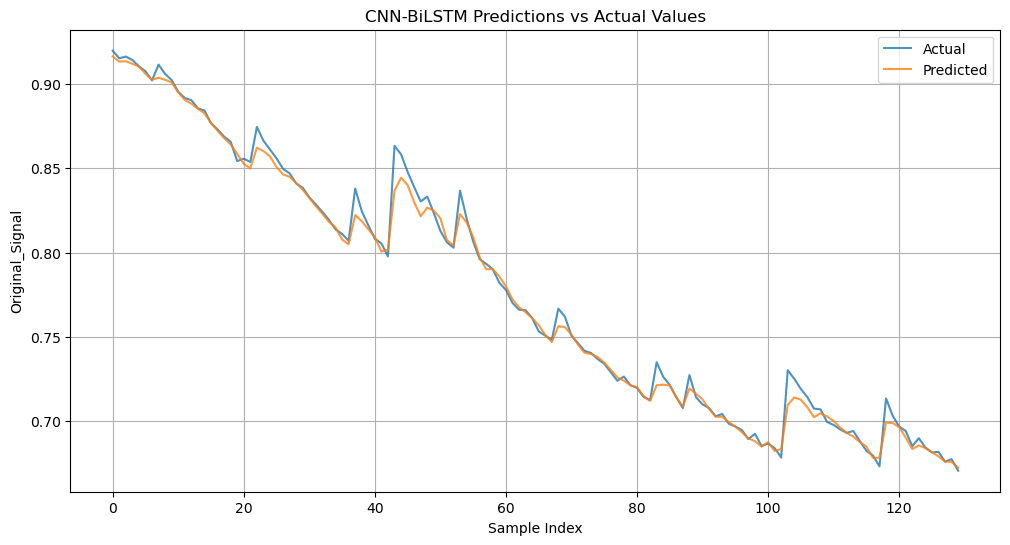


Output shapes:
Actual values shape: (130,)
Predicted values shape: (130,)


In [14]:
 #Plot the predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label="Actual", alpha=0.8)
plt.plot(y_pred_actual, label="Predicted", alpha=0.8)
plt.title("CNN-BiLSTM Predictions vs Actual Values")
plt.xlabel("Sample Index")
plt.ylabel("Original_Signal")
plt.legend()
plt.grid(True)
plt.show()

print("\nOutput shapes:")
print(f"Actual values shape: {y_test_actual.shape}")
print(f"Predicted values shape: {y_pred_actual.shape}")

In [15]:
# Save results
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Save predictions
predictions_df = pd.DataFrame({
    'Actual': y_test_actual,
    'Predicted': y_pred_actual,
    'Error': y_test_actual - y_pred_actual
})
predictions_filename = f'CNN_lstm_predictions_{test_file}_{timestamp}.csv'
predictions_df.to_csv(predictions_filename, index=True)
    
    # Save metrics
metrics_df = pd.DataFrame({
    'Metric': ['Test Loss', 'MAE', 'MSE', 'RMSE', 'R2', 'MAPE'],
    'Value': [test_loss, mae, mse, rmse, r2, mape]
})
metrics_filename = f'CNN_bigru_metrics_{test_file}_{timestamp}.csv'
metrics_df.to_csv(metrics_filename, index=False)

In [2]:
from tensorflow.keras.layers import GRU, Bidirectional

In [3]:
#B0005

In [4]:
# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '0'

In [5]:
# File paths
file_paths = {
    "B0005": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0005_ALL_FEATURES_NEW.csv",
    "B0006": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0006_ALL_FEATURES_NEW.csv",
    "B0007": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0007_ALL_FEATURES_NEW.csv",
    "B0018": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0018_ALL_FEATURES_NEW.csv"
}

In [6]:
def load_and_preprocess_data(file_path):
    data = pd.read_csv(file_path)
      # Drop specified columns
    #data = data.drop(columns=['IMF1', 'IMF2', 'IMF3'])
    #group 1
    #data = data.drop(columns=['IMF1', 'IMF2', 'IMF3','CV_CT', 'dQ_dV_peak_positionV'])
    
    # group 2
    data = data.drop(columns=['CC_CT','CV_CT','Ratio_CCCT_CVCT','C_TEMP_MAX','dQ_dV_peak','dQ_dV_peak_positionV','Original_Signal'])

    #group 1 and 2
    #data = data.drop(columns=['CV_CT','dQ_dV_peak', 'dQ_dV_peak_positionV'])
    return data


In [7]:
def create_sliding_window(data, window_size, target_column_index):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size, :])
        y.append(data[i + window_size, target_column_index])
    return np.array(X), np.array(y)

In [8]:
# Define parameters
window_size = 2
Batch_Size = 32
train_files = ["B0018", "B0006", "B0007"]
test_file = "B0005"

In [9]:
# Step 1: Load and preprocess individual datasets
train_processed_data = {}
for file in train_files:
    data = load_and_preprocess_data(file_paths[file])
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    train_processed_data[file] = {
        'data': scaled_data,
        'columns': data.columns,
        'scaler': scaler
    }

test_data = load_and_preprocess_data(file_paths[test_file])
test_scaler = MinMaxScaler()
test_data_scaled = test_scaler.fit_transform(test_data)

In [10]:
# Step 2: Create sliding windows for each dataset
train_windows = {}
for file in train_files:
    #target_column_index = list(train_processed_data[file]['columns']).index("Original_Signal")
    target_column_index = list(train_processed_data[file]['columns']).index("SOH")
    X, y = create_sliding_window(
        train_processed_data[file]['data'], 
        window_size, 
        target_column_index
    )
    train_windows[file] = {'X': X, 'y': y}

In [11]:
# Step 3: Combine the windowed data
X_combined = np.concatenate([train_windows[file]['X'] for file in train_files])
y_combined = np.concatenate([train_windows[file]['y'] for file in train_files])

print("Combined training data shape:", X_combined.shape)
print("Combined target data shape:", y_combined.shape)

# Create sliding windows for test data
test_target_column_index = test_data.columns.get_loc("SOH")
X_test, y_test = create_sliding_window(test_data_scaled, window_size, test_target_column_index)
print("Test data shape:", X_test.shape)

# Initialize KFold
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Dictionary to store metrics for each fold
fold_metrics = {}

# Train and evaluate the model with K-Fold Cross Validation
for fold, (train_index, val_index) in enumerate(kf.split(X_combined)):
    print(f"\nTraining on fold {fold + 1}")
    
    # Split the data
    X_train, X_val = X_combined[train_index], X_combined[val_index]
    y_train, y_val = y_combined[train_index], y_combined[val_index]
    
    # Build the CNN–BiGRU model
    model = Sequential([
        # --- CNN Feature Extractor ---
        TimeDistributed(Conv1D(filters=128, kernel_size=1, activation='relu'), 
                        input_shape=(window_size, X_train.shape[2], 1)),
        TimeDistributed(MaxPooling1D(pool_size=1)),
        
        TimeDistributed(Conv1D(filters=128, kernel_size=1, activation='relu')),
        TimeDistributed(MaxPooling1D(pool_size=1)),
        
        # Flatten CNN output while keeping time dimension
        TimeDistributed(Flatten()),
        
        # --- Bidirectional GRU Layer ---
        Bidirectional(GRU(64, return_sequences=False, activation='relu')),
        
        # --- Output Layer ---
        Dense(1)
    ])
    
    # Reshape input data for CNN-BiGRU
    X_train_reshaped = X_train.reshape(X_train.shape[0], window_size, X_train.shape[2], 1)
    X_val_reshaped = X_val.reshape(X_val.shape[0], window_size, X_val.shape[2], 1)
    
    # Compile model
    model.compile(optimizer='adam', loss='mse')
    
    # Early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

    # Train model
    history = model.fit(
        X_train_reshaped, y_train,
        validation_data=(X_val_reshaped, y_val),
        epochs=1000,
        batch_size=Batch_Size,
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Store metrics for this fold
    fold_metrics[fold] = {
        'val_loss': min(history.history['val_loss']),
        'train_loss': min(history.history['loss'])
    }

# Print average metrics across folds
avg_val_loss = np.mean([metrics['val_loss'] for metrics in fold_metrics.values()])
print(f"\nAverage validation loss across folds: {avg_val_loss}")

# Reshape test data for prediction
X_test_reshaped = X_test.reshape(X_test.shape[0], window_size, X_test.shape[2], 1)

# Evaluate on test set
test_loss = model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"Test Loss: {test_loss}")

# Predict on the test set
y_pred = model.predict(X_test_reshaped)

# Inverse transform the predictions and actual values using test_scaler
y_test_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_test), test_data.shape[1] - 1)), y_test.reshape(-1, 1)), axis=1)
)[:, -1]

y_pred_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_pred), test_data.shape[1] - 1)), y_pred), axis=1)
)[:, -1]


Combined training data shape: (462, 2, 4)
Combined target data shape: (462,)
Test data shape: (166, 2, 4)

Training on fold 1


C:\Users\Varshitha\anaconda3\Lib\site-packages\keras\src\layers\core\wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 214ms/step - loss: 0.1540 - val_loss: 0.0425
Epoch 2/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0383 - val_loss: 0.0223
Epoch 3/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0128 - val_loss: 0.0052
Epoch 4/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0028 - val_loss: 0.0014
Epoch 5/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0018 - val_loss: 9.6719e-04
Epoch 6/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0012 - val_loss: 0.0010
Epoch 7/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.0011 - val_loss: 7.6892e-04
Epoch 8/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 9.1405e-04 - val_loss: 6.5738e-04
Epoch 9/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 8.2688e-04 - val_loss: 6.0391e-04
Epoch 10/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 7.7611e-04 - val_loss: 5.4647e-04
Epoch 11/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 7.0708e-04 - val_loss: 4.9620e-04

In [12]:
# Calculate metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_actual)
-mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

# Print metrics
print("\nFinal Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.10f}")
print(f"Mean Squared Error (MSE): {mse:.10f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.10f}")
print(f"R2 Score: {r2:.7f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.7f}%")


Final Model Performance Metrics:
Mean Absolute Error (MAE): 0.0018950095
Mean Squared Error (MSE): 0.0000075597
Root Mean Squared Error (RMSE): 0.0027494829
R2 Score: 0.9991488
Mean Absolute Percentage Error (MAPE): 0.2425695%


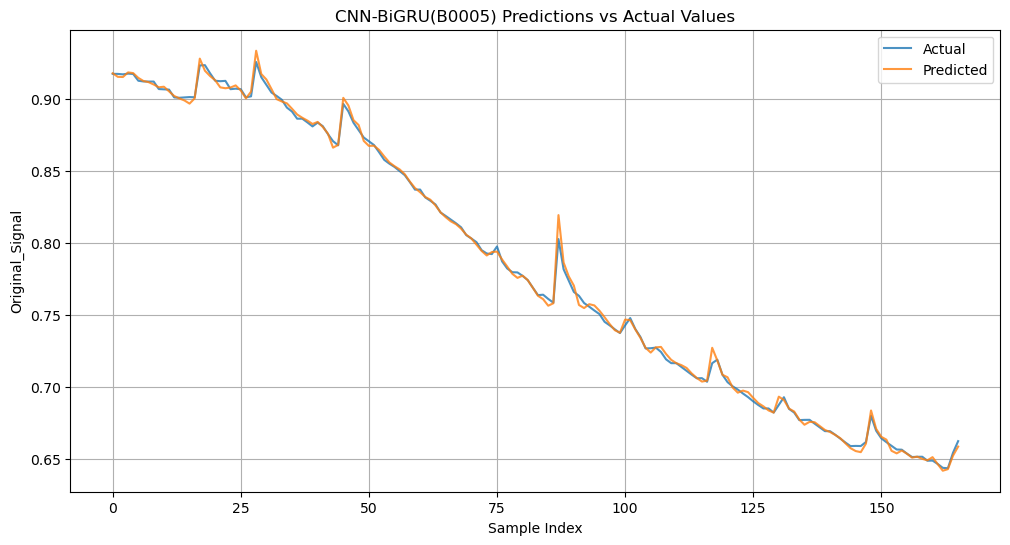


Output shapes:
Actual values shape: (166,)
Predicted values shape: (166,)


In [13]:
#Plot the predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label="Actual", alpha=0.8)
plt.plot(y_pred_actual, label="Predicted", alpha=0.8)
plt.title("CNN-BiGRU(B0005) Predictions vs Actual Values")
plt.xlabel("Sample Index")
plt.ylabel("Original_Signal")
plt.legend()
plt.grid(True)
plt.show()

print("\nOutput shapes:")
print(f"Actual values shape: {y_test_actual.shape}")
print(f"Predicted values shape: {y_pred_actual.shape}")

In [14]:
#B0006

In [15]:
# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '0'

In [16]:
# File paths
file_paths = {
    "B0005": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0005_ALL_FEATURES_NEW.csv",
    "B0006": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0006_ALL_FEATURES_NEW.csv",
    "B0007": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0007_ALL_FEATURES_NEW.csv",
    "B0018": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0018_ALL_FEATURES_NEW.csv"
}

In [17]:
def load_and_preprocess_data(file_path):
    data = pd.read_csv(file_path)
      # Drop specified columns
    #data = data.drop(columns=['IMF1', 'IMF2', 'IMF3'])
    #group 1
    #data = data.drop(columns=['IMF1', 'IMF2', 'IMF3','CV_CT', 'dQ_dV_peak_positionV'])
    
    # group 2
    data = data.drop(columns=['CC_CT','CV_CT','Ratio_CCCT_CVCT','C_TEMP_MAX','dQ_dV_peak','dQ_dV_peak_positionV','Original_Signal'])

    #group 1 and 2
    #data = data.drop(columns=['CV_CT','dQ_dV_peak', 'dQ_dV_peak_positionV'])
    return data


In [18]:
def create_sliding_window(data, window_size, target_column_index):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size, :])
        y.append(data[i + window_size, target_column_index])
    return np.array(X), np.array(y)

In [19]:
# Define parameters
window_size = 2
Batch_Size = 32
train_files = ["B0005", "B0018", "B0007"]
test_file = "B0006"

In [20]:
# Step 1: Load and preprocess individual datasets
train_processed_data = {}
for file in train_files:
    data = load_and_preprocess_data(file_paths[file])
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    train_processed_data[file] = {
        'data': scaled_data,
        'columns': data.columns,
        'scaler': scaler
    }

test_data = load_and_preprocess_data(file_paths[test_file])
test_scaler = MinMaxScaler()
test_data_scaled = test_scaler.fit_transform(test_data)

In [21]:
# Step 2: Create sliding windows for each dataset
train_windows = {}
for file in train_files:
    #target_column_index = list(train_processed_data[file]['columns']).index("Original_Signal")
    target_column_index = list(train_processed_data[file]['columns']).index("SOH")
    X, y = create_sliding_window(
        train_processed_data[file]['data'], 
        window_size, 
        target_column_index
    )
    train_windows[file] = {'X': X, 'y': y}

In [22]:
# Step 3: Combine the windowed data
X_combined = np.concatenate([train_windows[file]['X'] for file in train_files])
y_combined = np.concatenate([train_windows[file]['y'] for file in train_files])

print("Combined training data shape:", X_combined.shape)
print("Combined target data shape:", y_combined.shape)

# Create sliding windows for test data
test_target_column_index = test_data.columns.get_loc("SOH")
X_test, y_test = create_sliding_window(test_data_scaled, window_size, test_target_column_index)
print("Test data shape:", X_test.shape)

# Initialize KFold
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Dictionary to store metrics for each fold
fold_metrics = {}

# Train and evaluate the model with K-Fold Cross Validation
for fold, (train_index, val_index) in enumerate(kf.split(X_combined)):
    print(f"\nTraining on fold {fold + 1}")
    
    # Split the data
    X_train, X_val = X_combined[train_index], X_combined[val_index]
    y_train, y_val = y_combined[train_index], y_combined[val_index]
    
    # Build the CNN–BiGRU model
    model = Sequential([
        # --- CNN Feature Extractor ---
        TimeDistributed(Conv1D(filters=128, kernel_size=1, activation='relu'), 
                        input_shape=(window_size, X_train.shape[2], 1)),
        TimeDistributed(MaxPooling1D(pool_size=1)),
        
        TimeDistributed(Conv1D(filters=128, kernel_size=1, activation='relu')),
        TimeDistributed(MaxPooling1D(pool_size=1)),
        
        # Flatten CNN output while keeping time dimension
        TimeDistributed(Flatten()),
        
        # --- Bidirectional GRU Layer ---
        Bidirectional(GRU(64, return_sequences=False, activation='relu')),
        
        # --- Output Layer ---
        Dense(1)
    ])
    
    # Reshape input data for CNN-BiGRU
    X_train_reshaped = X_train.reshape(X_train.shape[0], window_size, X_train.shape[2], 1)
    X_val_reshaped = X_val.reshape(X_val.shape[0], window_size, X_val.shape[2], 1)
    
    # Compile model
    model.compile(optimizer='adam', loss='mse')
    
    # Early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

    # Train model
    history = model.fit(
        X_train_reshaped, y_train,
        validation_data=(X_val_reshaped, y_val),
        epochs=1000,
        batch_size=Batch_Size,
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Store metrics for this fold
    fold_metrics[fold] = {
        'val_loss': min(history.history['val_loss']),
        'train_loss': min(history.history['loss'])
    }

# Print average metrics across folds
avg_val_loss = np.mean([metrics['val_loss'] for metrics in fold_metrics.values()])
print(f"\nAverage validation loss across folds: {avg_val_loss}")

# Reshape test data for prediction
X_test_reshaped = X_test.reshape(X_test.shape[0], window_size, X_test.shape[2], 1)

# Evaluate on test set
test_loss = model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"Test Loss: {test_loss}")

# Predict on the test set
y_pred = model.predict(X_test_reshaped)

# Inverse transform the predictions and actual values using test_scaler
y_test_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_test), test_data.shape[1] - 1)), y_test.reshape(-1, 1)), axis=1)
)[:, -1]

y_pred_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_pred), test_data.shape[1] - 1)), y_pred), axis=1)
)[:, -1]


Combined training data shape: (462, 2, 4)
Combined target data shape: (462,)
Test data shape: (166, 2, 4)

Training on fold 1


C:\Users\Varshitha\anaconda3\Lib\site-packages\keras\src\layers\core\wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 230ms/step - loss: 0.1583 - val_loss: 0.0398
Epoch 2/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0406 - val_loss: 0.0275
Epoch 3/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0138 - val_loss: 0.0044
Epoch 4/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0027 - val_loss: 0.0027
Epoch 5/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0019 - val_loss: 0.0015
Epoch 6/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0011 - val_loss: 9.9035e-04
Epoch 7/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 8.4914e-04 - val_loss: 0.0010
Epoch 8/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 7.7956e-04 - val_loss: 0.0010
Epoch 9/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 7.4270e-04 - val_loss: 8.5871e-04
Epoch 10/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 6.6653e-04 - val_loss: 8.0549e-04
Epoch 11/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 6.2148e-04 - val_loss: 7.7980e-04
Epo

In [23]:
# Calculate metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_actual)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

# Print metrics
print("\nFinal Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.10f}")
print(f"Mean Squared Error (MSE): {mse:.10f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.10f}")
print(f"R2 Score: {r2:.7f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.7f}%")


Final Model Performance Metrics:
Mean Absolute Error (MAE): 0.0031834198
Mean Squared Error (MSE): 0.0000183378
Root Mean Squared Error (RMSE): 0.0042822622
R2 Score: 0.9987986
Mean Absolute Percentage Error (MAPE): 0.4062374%


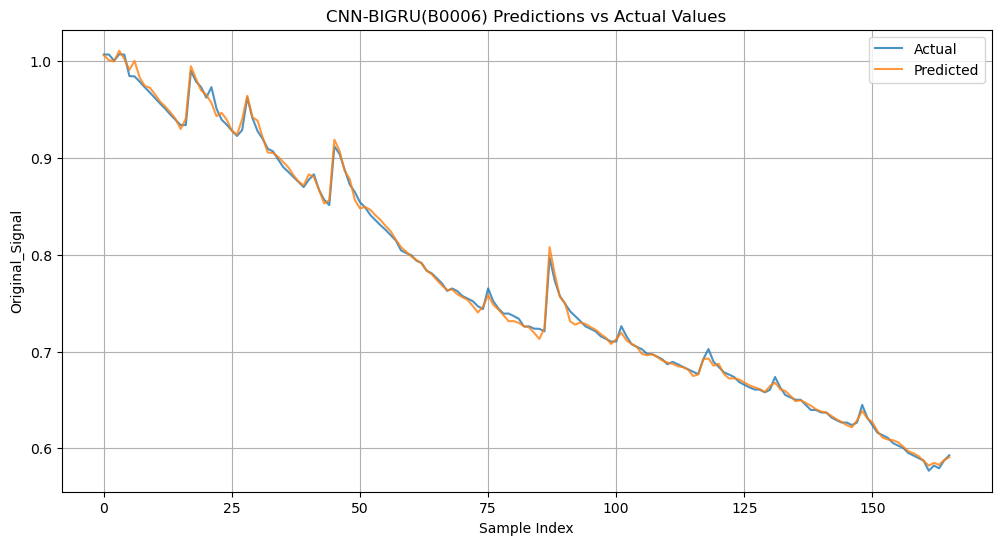


Output shapes:
Actual values shape: (166,)
Predicted values shape: (166,)


In [24]:
#Plot the predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label="Actual", alpha=0.8)
plt.plot(y_pred_actual, label="Predicted", alpha=0.8)
plt.title("CNN-BIGRU(B0006) Predictions vs Actual Values")
plt.xlabel("Sample Index")
plt.ylabel("Original_Signal")
plt.legend()
plt.grid(True)
plt.show()

print("\nOutput shapes:")
print(f"Actual values shape: {y_test_actual.shape}")
print(f"Predicted values shape: {y_pred_actual.shape}")

In [25]:
#B0007

In [26]:
# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '0'

In [27]:
# File paths
file_paths = {
    "B0005": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0005_ALL_FEATURES_NEW.csv",
    "B0006": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0006_ALL_FEATURES_NEW.csv",
    "B0007": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0007_ALL_FEATURES_NEW.csv",
    "B0018": r"C:\Users\Varshitha\OneDrive\CU notes\RM\VMD_CNN_LSTM_CODE_VIJAY\B0018_ALL_FEATURES_NEW.csv"
}

In [28]:
def load_and_preprocess_data(file_path):
    data = pd.read_csv(file_path)
      # Drop specified columns
    #data = data.drop(columns=['IMF1', 'IMF2', 'IMF3'])
    #group 1
    #data = data.drop(columns=['IMF1', 'IMF2', 'IMF3','CV_CT', 'dQ_dV_peak_positionV'])
    
    # group 2
    data = data.drop(columns=['CC_CT','CV_CT','Ratio_CCCT_CVCT','C_TEMP_MAX','dQ_dV_peak','dQ_dV_peak_positionV','Original_Signal'])

    #group 1 and 2
    #data = data.drop(columns=['CV_CT','dQ_dV_peak', 'dQ_dV_peak_positionV'])
    return data


In [29]:
def create_sliding_window(data, window_size, target_column_index):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size, :])
        y.append(data[i + window_size, target_column_index])
    return np.array(X), np.array(y)

In [30]:
# Define parameters
window_size = 2
Batch_Size = 32
train_files = ["B0005", "B0006", "B0018"]
test_file = "B0007"

In [31]:
# Step 1: Load and preprocess individual datasets
train_processed_data = {}
for file in train_files:
    data = load_and_preprocess_data(file_paths[file])
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    train_processed_data[file] = {
        'data': scaled_data,
        'columns': data.columns,
        'scaler': scaler
    }

test_data = load_and_preprocess_data(file_paths[test_file])
test_scaler = MinMaxScaler()
test_data_scaled = test_scaler.fit_transform(test_data)

In [32]:
# Step 2: Create sliding windows for each dataset
train_windows = {}
for file in train_files:
    #target_column_index = list(train_processed_data[file]['columns']).index("Original_Signal")
    target_column_index = list(train_processed_data[file]['columns']).index("SOH")
    X, y = create_sliding_window(
        train_processed_data[file]['data'], 
        window_size, 
        target_column_index
    )
    train_windows[file] = {'X': X, 'y': y}

In [33]:
# Step 3: Combine the windowed data
X_combined = np.concatenate([train_windows[file]['X'] for file in train_files])
y_combined = np.concatenate([train_windows[file]['y'] for file in train_files])

print("Combined training data shape:", X_combined.shape)
print("Combined target data shape:", y_combined.shape)

# Create sliding windows for test data
test_target_column_index = test_data.columns.get_loc("SOH")
X_test, y_test = create_sliding_window(test_data_scaled, window_size, test_target_column_index)
print("Test data shape:", X_test.shape)

# Initialize KFold
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Dictionary to store metrics for each fold
fold_metrics = {}

# Train and evaluate the model with K-Fold Cross Validation
for fold, (train_index, val_index) in enumerate(kf.split(X_combined)):
    print(f"\nTraining on fold {fold + 1}")
    
    # Split the data
    X_train, X_val = X_combined[train_index], X_combined[val_index]
    y_train, y_val = y_combined[train_index], y_combined[val_index]
    
    # Build the CNN–BiGRU model
    model = Sequential([
        # --- CNN Feature Extractor ---
        TimeDistributed(Conv1D(filters=128, kernel_size=1, activation='relu'), 
                        input_shape=(window_size, X_train.shape[2], 1)),
        TimeDistributed(MaxPooling1D(pool_size=1)),
        
        TimeDistributed(Conv1D(filters=128, kernel_size=1, activation='relu')),
        TimeDistributed(MaxPooling1D(pool_size=1)),
        
        # Flatten CNN output while keeping time dimension
        TimeDistributed(Flatten()),
        
        # --- Bidirectional GRU Layer ---
        Bidirectional(GRU(64, return_sequences=False, activation='relu')),
        
        # --- Output Layer ---
        Dense(1)
    ])
    
    # Reshape input data for CNN-BiGRU
    X_train_reshaped = X_train.reshape(X_train.shape[0], window_size, X_train.shape[2], 1)
    X_val_reshaped = X_val.reshape(X_val.shape[0], window_size, X_val.shape[2], 1)
    
    # Compile model
    model.compile(optimizer='adam', loss='mse')
    
    # Early stopping
    early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

    # Train model
    history = model.fit(
        X_train_reshaped, y_train,
        validation_data=(X_val_reshaped, y_val),
        epochs=1000,
        batch_size=Batch_Size,
        callbacks=[early_stopping],
        verbose=1
    )
    
    # Store metrics for this fold
    fold_metrics[fold] = {
        'val_loss': min(history.history['val_loss']),
        'train_loss': min(history.history['loss'])
    }

# Print average metrics across folds
avg_val_loss = np.mean([metrics['val_loss'] for metrics in fold_metrics.values()])
print(f"\nAverage validation loss across folds: {avg_val_loss}")

# Reshape test data for prediction
X_test_reshaped = X_test.reshape(X_test.shape[0], window_size, X_test.shape[2], 1)

# Evaluate on test set
test_loss = model.evaluate(X_test_reshaped, y_test, verbose=0)
print(f"Test Loss: {test_loss}")

# Predict on the test set
y_pred = model.predict(X_test_reshaped)

# Inverse transform the predictions and actual values using test_scaler
y_test_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_test), test_data.shape[1] - 1)), y_test.reshape(-1, 1)), axis=1)
)[:, -1]

y_pred_actual = test_scaler.inverse_transform(
    np.concatenate((np.zeros((len(y_pred), test_data.shape[1] - 1)), y_pred), axis=1)
)[:, -1]


Combined training data shape: (462, 2, 4)
Combined target data shape: (462,)
Test data shape: (166, 2, 4)

Training on fold 1


C:\Users\Varshitha\anaconda3\Lib\site-packages\keras\src\layers\core\wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 224ms/step - loss: 0.1447 - val_loss: 0.0424
Epoch 2/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0376 - val_loss: 0.0260
Epoch 3/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0139 - val_loss: 0.0057
Epoch 4/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0032 - val_loss: 0.0016
Epoch 5/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - loss: 0.0017 - val_loss: 0.0011
Epoch 6/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0012 - val_loss: 8.8457e-04
Epoch 7/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0010 - val_loss: 7.2208e-04
Epoch 8/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 8.8580e-04 - val_loss: 6.4507e-04
Epoch 9/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 8.3388e-04 - val_loss: 6.0169e-04
Epoch 10/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 7.3379e-04 - val_loss: 4.9052e-04
Epoch 11/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 6.5701e-04 - val_loss: 4.4361e-04

In [34]:
# Calculate metrics
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_actual)
mape = np.mean(np.abs((y_test_actual - y_pred_actual) / y_test_actual)) * 100

# Print metrics
print("\nFinal Model Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.10f}")
print(f"Mean Squared Error (MSE): {mse:.10f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.10f}")
print(f"R2 Score: {r2:.7f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.7f}%")


Final Model Performance Metrics:
Mean Absolute Error (MAE): 0.0016440892
Mean Squared Error (MSE): 0.0000052161
Root Mean Squared Error (RMSE): 0.0022838872
R2 Score: 0.9991769
Mean Absolute Percentage Error (MAPE): 0.1993654%


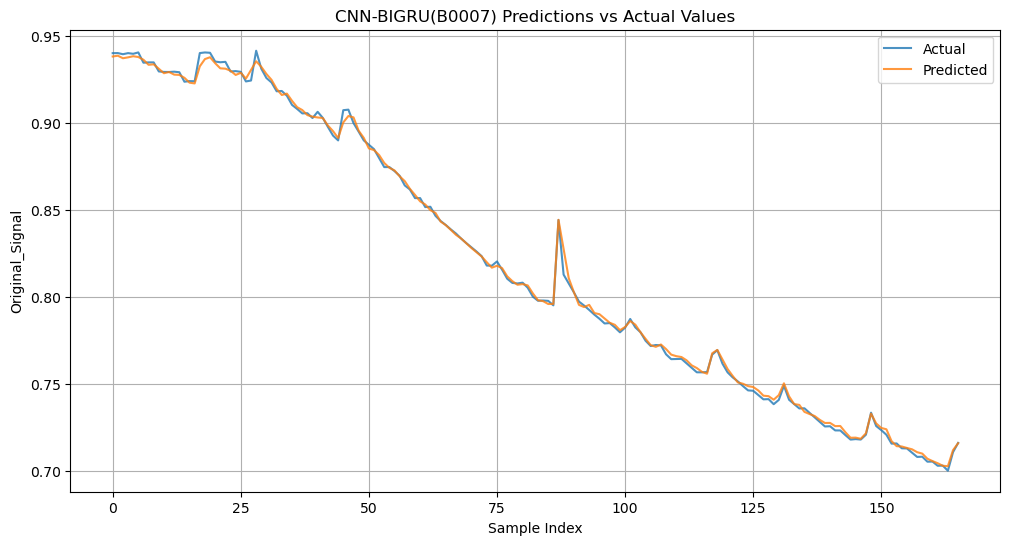


Output shapes:
Actual values shape: (166,)
Predicted values shape: (166,)


In [35]:
#Plot the predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label="Actual", alpha=0.8)
plt.plot(y_pred_actual, label="Predicted", alpha=0.8)
plt.title("CNN-BIGRU(B0007) Predictions vs Actual Values")
plt.xlabel("Sample Index")
plt.ylabel("Original_Signal")
plt.legend()
plt.grid(True)
plt.show()

print("\nOutput shapes:")
print(f"Actual values shape: {y_test_actual.shape}")
print(f"Predicted values shape: {y_pred_actual.shape}")

In [36]:
model.summary()
total_params = model.count_params()
print(f"Total trainable parameters in {model.name if hasattr(model, 'name') else 'model'}: {total_params:,}")


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape          ┃      Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ time_distributed_40           │ (None, 2, 4, 128)     │          256 │
│ (TimeDistributed)             │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ time_distributed_41           │ (None, 2, 4, 128)     │            0 │
│ (TimeDistributed)             │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ time_distributed_42           │ (None, 2, 4, 128)     │       16,512 │
│ (TimeDistributed)             │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ time_distributed_43           │ (None, 2, 4, 128)     │            0 │
│ (TimeDistributed)             │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ time_distributed_44           │ (None, 2, 512)        │            0 │
│ (TimeDistributed)             │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ bidirectional_8               │ (None, 128)           │      221,952 │
│ (Bidirectional)               │                       │              │
├───────────────────────────────┼───────────────────────┼──────────────┤
│ dense_8 (Dense)               │ (None, 1)             │          129 │
└───────────────────────────────┴───────────────────────┴──────────────┘

 Total params: 716,549 (2.73 MB)

 Trainable params: 238,849 (933.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 477,700 (1.82 MB)

Total trainable parameters in sequential_8: 238,849
